<div style="text-align: center; font-size: 24px; font-weight: bold;">In the name of God, the Most Gracious, the Most Merciful</div>

Full Name: Mohammadmahdi Bababeyk

Student ID: 4041419005

# Building Neural Network Using Torch

This assignment is structured to mirror a standard machine learning workflow, broken down into distinct, logical stages:

1. Data Loading and Inspection: We begin by loading the dataset and performing an initial exploration to understand its structure, features, and potential data quality issues.

2. Data Preprocessing: Raw data is seldom suitable for model training. This stage involves critical steps such as data cleaning (e.g., correcting data types), splitting the data into training, validation, and test sets, and standardizing the features to ensure stable and efficient model convergence.

3. Model Design: We define the architecture of our neural network using PyTorch's nn.Module.

4. Training Loop Design: The heart of the learning process is implemented here. This involves defining a loss function (Mean Squared Error for regression), selecting an optimizer (e.g. Adam), and constructing a robust training loop that iterates over the data, performs forward and backward propagation, and tracks performance on a validation set to monitor for overfitting.

5. Evaluation and Visualization: After training, the model's predictive power is quantitatively assessed on a held-out test set using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the R-squared (R²) score. Furthermore, the results are visualized through training/validation loss curves and a scatter plot of predicted vs. actual prices, providing an intuitive understanding of the model's accuracy.

By completing this assignment, we aim to solidify our understanding of the end-to-end process of developing a neural network, from data preparation to deployment and evaluation, using the powerful and flexible PyTorch framework. The following sections document this process in detail, including code implementation, results, and analysis.

## 1.Load and Inspect the Data

### Practice 1

Task 1: Load the Dataset

- Question: Load the BostonHousing.csv file into a variable named df.

  **Hint**: You will need to use a function from the pandas library to read a CSV file. Don't forget to import the library first.

Task 2: Initial Inspection

- Question 2.1: Print the shape of the DataFrame to find out how many samples and features it contains.

  **Hint**: DataFrames have a .shape attribute.

- Question 2.2: Print a list of the column names.

  **Hint**: DataFrames have a .columns attribute. You can convert it to a list for a cleaner printout.

- Question 2.3: Display the first 5 rows of the DataFrame to get a feel for the actual data.

  **Hint**: There is a simple DataFrame method to show the first n rows.

Task 3: Data Cleaning

- Question 3.1: The 'chas' column should be a binary integer (0 or 1), but it was likely read as a string. Convert this column to an integer data type.

  **Hint**: You can assign a new data type to a column using .astype().

- Question 3.2: Check if the dataset has any missing (NaN) values. Print the number of missing values for each column.

  **Hint**: Combine the .isnull() and .sum() methods on the DataFrame.

- Question 3.3: Check if there are any infinite values in the dataset. The final output should be a single boolean (True or False).

  **Hint**: You can compare the entire DataFrame (df) with float('inf') and then use .any().any() to collapse the result into a single value.

In [6]:
import pandas as pd

# Task 1: Load the dataset
df = pd.read_csv("BostonHousing.csv")

# Task 2: Initial inspection
print("Shape:", df.shape)                      # Q2.1
print("\nColumns:\n", list(df.columns))        # Q2.2
print("\nSample rows:\n", df.head())           # Q2.3

# Task 3: Data Cleaning
df['chas'] = df['chas'].astype(int)            # Q3.1
print("\nMissing values:\n", df.isnull().sum()) # Q3.2

has_infinite = (df == float('inf')).any().any() # Q3.3
print("\nContains infinite values?", has_infinite)


Shape: (506, 14)

Columns:
 ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Sample rows:
       crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Missing values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Contai

Let’s clean "chas" (it's a string "0"/"1" due to CSV quoting):

## 2.Data Preprocessing

### practice 2
Now, you will prepare the loaded data for training a neural network. This involves separating features from the target, splitting the data into sets for training, validation, and testing, and normalizing the features.

Objective: Your goal is to transform the raw DataFrame into PyTorch tensors that are properly scaled and split for model training and evaluation.
Tasks:

Task 1: Separate Features and Target

- Question 1.1: Create a variable X containing all the features (all columns except the target 'medv'). Convert the values to np.float32.

  **Hint**: Use df.drop() to remove the target column. The .values attribute gives you a NumPy array.

- Question 1.2: Create a variable y containing only the target column ('medv'). Convert the values to np.float32.

  **Hint**: You can select the column directly and use .values.

Task 2: Split the Data
We will create three sets:

- Training set: Used to train the model.

- Validation set: Used to evaluate the model during training and tune hyperparameters.

- Test set: Used for the final evaluation of the model.

- Question 2.1: First, split the data temporarily into X_temp, X_test, y_temp, y_test, using a 15% test size.

  **Hint**: Use train_test_split from sklearn. Set test_size=0.15 and use a random_state=42 for reproducible results.

- Question 2.2: Now, split the temporary data (X_temp, y_temp) into the final training and validation sets. The validation set should be 15% of the original data. Calculate the test_size for this second split accordingly (≈0.1765).

  **Hint**: 0.1765 is approximately 15/85. Use random_state=42 again.

Task 3: Normalize the Features
Neural networks perform much better with normalized data. We will standardize the features (subtract mean, divide by standard deviation).

- Question 3.1: Calculate the mean (train_mean) and standard deviation (train_std) using only the training data (X_train).

  **Hint**: Use .mean(axis=0) and .std(axis=0) on X_train.

- Question 3.2: To avoid division by zero, replace any standard deviation value of 0 with 1.0.

  **Hint**: Use np.where(train_std == 0, 1.0, train_std).

- Question 3.3: Use the training mean and standard deviation to normalize X_train, X_val, and X_test.

  **Hint**: Apply the formula: (data - train_mean) / train_std.

Task 4: Convert to PyTorch Tensors

- Question 4.1: Convert the normalized training, validation, and test features (X_train_norm, X_val_norm, X_test_norm) into PyTorch tensors.

  **Hint**: Use torch.tensor().

- Question 4.2: Convert the target variables (y_train, y_val, y_test) into PyTorch tensors. Ensure their shape is [N, 1] for regression (where N is the number of samples), not [N].

  **Hint**: Use .unsqueeze(1) on the tensor to add an extra dimension.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# Task 1.1: Features (all columns except 'medv')
X = df.drop('medv', axis=1).values.astype(np.float32)   # (506, 13)

# Task 1.2: Target ('medv')
y = df['medv'].values.astype(np.float32)                # (506,)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

print(f"Splits: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")


Splits: train=354, val=76, test=76


Normalize features (standardization: (x - μ)/σ)

In [8]:
# Compute mean and std from TRAIN only
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
# Avoid division by zero
train_std = np.where(train_std == 0, 1.0, train_std)

# Normalize
# Normalize
X_train_norm = (X_train - train_mean) / train_std
X_val_norm   = (X_val   - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std


# Training set
X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

# Validation set
X_val_t = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# Test set
X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

print("Shapes after normalization & unsqueeze:")
print(f"X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")

Shapes after normalization & unsqueeze:
X_train: torch.Size([354, 13]), y_train: torch.Size([354, 1])


Create Custom Dataset Class

### practice 3
In this section, you will create a custom Dataset class and DataLoader objects. This is a crucial step for efficiently feeding data in batches to your neural network during training.

Objective: Your goal is to wrap the preprocessed tensors into a PyTorch Dataset and then create DataLoader objects that will handle batching and shuffling.
Tasks:

Task 1: Create a Custom Dataset Class
A Dataset class is required to tell PyTorch how to access your data.

- Question 1.1: Create a class called BostonDataset that inherits from torch.utils.data.Dataset.

- Question 1.2: Define the __init__ method. It should take X (features) and y (targets) as input and store them as instance attributes (e.g., self.X and self.y).

- Question 1.3: Define the __len__ method. It should return the total number of samples in the dataset.

  **Hint**: The length is simply the number of rows in self.X (or self.y).

- Question 1.4: Define the __getitem__ method. It takes an index idx and should return a tuple containing the features and the target for that single sample: (self.X[idx], self.y[idx]).

Task 2: Instantiate Dataset Objects

- Question 2.1: Create three dataset objects: train_dataset, val_dataset, and test_dataset using the BostonDataset class you just defined.

  **Hint**: Use the tensors you created in the previous section (X_train_t, y_train_t, etc.).

Task 3: Create DataLoader Objects
DataLoaders wrap the Dataset and provide features like batching and shuffling.

- Question 3.1: Create a DataLoader for the training dataset. Set the batch_size to 32 and shuffle=True. Why is shuffling important for the training set?

- Question 3.2: Create DataLoader objects for the validation and test datasets. Set batch_size to 32, but should you shuffle these sets? Why or why not?

  **Hint**: Think about the purpose of validation and testing – do we need the order of data to be random during evaluation?

In [9]:
from torch.utils.data import Dataset


In [10]:

class BostonDataset(Dataset):
    def __init__(self, X, y):
        # Store feature and target tensors
        self.X = X
        self.y = y

    def __len__(self):
        # Return number of samples
        return len(self.X)

    def __getitem__(self, idx):
        # Return one sample (features, target)
        return self.X[idx], self.y[idx]


Create DataLoaders

In [11]:
batch_size = 32

# Create Dataset objects
train_dataset = BostonDataset(X_train_t, y_train_t)
val_dataset   = BostonDataset(X_val_t, y_val_t)
test_dataset  = BostonDataset(X_test_t, y_test_t)

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches per epoch: train={len(train_loader)}, val={len(val_loader)}")


Batches per epoch: train=12, val=3


### practice 4
1. Why do we use a batch_size instead of processing the entire dataset at once?

2. Why is it important to shuffle the training data but not the validation/test data?

3. What would happen if you used a very small batch_size (like 1)? What about a very large one (like the entire dataset)?

<div dir="rtl" style="text-align: right;">
جواب سوال 1 : کاهش چشمگیر مصرف حافظه (RAM/GPU Memory) و امکان آموزش مدل‌های بزرگ حتی روی سخت‌افزارهای معمولی،
به‌روزرسانی وزن‌ها به‌صورت مکرر و سریع‌تر که منجر به همگرایی سریع‌تر و پایدارتر می‌شود،
ایجاد نوعی نویز مفید در گرادیان‌ها که به فرار از حداقل‌های محلی ضعیف (poor local minima) کمک می‌کند،
امکان استفاده از عملیات ماتریسی بهینه‌شده در کتابخانه‌های مدرن (مانند cuBLAS در GPU) که برای اندازه‌های متوسط دسته بسیار سریع‌تر است.
به همین دلیل، در عمل تقریباً همیشه از batch_sizeهای کوچک تا متوسط (۱۶، ۳۲، ۶۴، ۱۲۸ و …) استفاده می‌شود.
<br>
<br>
جواب سوال 2: داده‌های آموزشی را در هر اپوک به‌صورت تصادفی shuffle می‌کنیم تا ترتیب نمونه‌ها ثابت نباشد. این کار از یادگیری الگوهای ناخواسته مرتبط با ترتیب داده‌ها جلوگیری می‌کند و باعث می‌شود مدل به‌خوبی تعمیم دهد.
داده‌های اعتبارسنجی (validation) و آزمون (test) را shuffle نمی‌کنیم زیرا هدف این مجموعه‌ها ارزیابی دقیق و تکرارپذیر عملکرد مدل است. تغییر ترتیب در هر بار اجرا باعث نوسان نتایج ارزیابی می‌شود و مقایسه عادلانه مدل‌ها یا تنظیم‌های مختلف را دشوار می‌کند. بنابراین ترتیب ثابت و مشخصی برای این دو مجموعه حفظ می‌شود.
<br>
<br>
جواب سوال 3: هنگامی که اندازه دسته برابر با یک در نظر گرفته شود (Stochastic Gradient Descent)، به‌روزرسانی وزن‌ها پس از مشاهده هر نمونه به‌صورت جداگانه انجام می‌شود. این روش نویز بسیار بالایی در تخمین گرادیان ایجاد می‌کند که می‌تواند به فرار از حداقل‌های محلی ضعیف و نقاط زینی کمک کند. با این حال، مسیر یادگیری به‌شدت پرنوسان و ناپایدار خواهد بود، همگرایی بسیار کند می‌شود، مصرف حافظه و زمان محاسباتی به‌دلیل تعداد بسیار بالای به‌روزرسانی‌ها افزایش می‌یابد و از توان محاسباتی موازی سخت‌افزار (به‌ویژه GPU) به‌صورت بهینه استفاده نمی‌شود.
در صورتی که اندازه دسته بسیار کوچک (مثلاً ۴ تا ۱۶) انتخاب شود، همچنان نویز قابل توجهی در گرادیان وجود دارد که به فرار از حداقل‌های محلی کمک می‌کند و سرعت همگرایی نسبت به حالت کامل بهتر است، اما نوسانات همچنان مشهود بوده و استفاده از توان محاسباتی GPU همچنان بهینه نیست. تنظیم نرخ یادگیری نیز حساس‌تر می‌شود.
در مقابل، اگر اندازه دسته معادل کل مجموعه آموزشی باشد (Full Batch Gradient Descent)، گرادیان در هر گام کاملاً دقیق و بدون نویز محاسبه می‌شود و مسیر به‌روزرسانی وزن‌ها بسیار صاف و پایدار است. اما این روش معایب جدی دارد: مصرف حافظه بسیار بالا (که اغلب روی کارت‌های گرافیک مدرن امکان‌پذیر نیست)، به‌روزرسانی وزن‌ها تنها یک‌بار در هر اپوک، سرعت یادگیری فوق‌العاده پایین، و احتمال گیر افتادن در حداقل‌های محلی ضعیف به‌دلیل فقدان نویز مفید.
در نتیجه، در عمل یادگیری عمیق امروزی تقریباً هیچ‌گاه از اندازه‌های دسته ۱ یا کل مجموعه داده استفاده نمی‌شود. اندازه‌های متوسط (۳۲، ۶۴، ۱۲۸ یا ۲۵۶) بهترین تعادل را بین سرعت همگرایی، پایداری، مصرف حافظه و بهره‌برداری بهینه از سخت‌افزار فراهم می‌آورند و به همین دلیل به‌عنوان استاندارد صنعتی پذیرفته شده‌اند.
</div>

## 3.Model Design

### practice 5
In this section, you will design the neural network architecture that will learn to predict house prices.

Objective: Your goal is to create neural network models using PyTorch's `nn.Module`, starting with a simple linear model.
Tasks:

Task 1: Implement a Linear Regressor (Single Layer)
This is the simplest model, with no hidden layers - just input to output.

- Question 1.1: Create a class LinearRegressor that inherits from nn.Module.

- Question 1.2: In the __init__ method, initialize the superclass and create a single linear layer (nn.Linear). The layer should have input_dim input features and output_dim output features. Use default parameters for the rest.

 **Hint**: The Boston dataset has 13 features, and we're predicting 1 value (price).

- Question 1.3: Define the forward method. It should take input x and pass it through the linear layer, then return the result.

Task 2: Instantiate and Examine a Model

- Question 2.1: Check if a GPU is available and set the device accordingly.

- Question 2.2: Create an instance of the LinearRegressor model with appropriate dimensions and move it to the available device.

- Question 2.3: Print the model architecture to examine its structure.

In [12]:
import torch
import torch.nn as nn

class LinearRegressor(nn.Module):
    def __init__(self, input_dim=13, output_dim=1):
        super(LinearRegressor, self).__init__()
        # Single fully connected layer (no hidden layers)
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Pass input through linear layer
        return self.linear(x)


Instantiate model

In [13]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the model and move it to the selected device
model = LinearRegressor(input_dim=13, output_dim=1).to(device)

print("Model architecture:")
print(model)


Using device: cuda
Model architecture:
LinearRegressor(
  (linear): Linear(in_features=13, out_features=1, bias=True)
)


### practice 6
1. What is the purpose of the forward method in a PyTorch model?

2. Why do we need to call super().__init__() in the __init__ method?

<div dir="rtl" style="text-align: right;">
جواب سوال 1 : متد forward در کلاس‌های مشتق‌شده از nn.Module، تنها مسیری است که تعریف می‌کند ورودی (x) چگونه از میان لایه‌های شبکه عصبی عبور کند و به خروجی نهایی تبدیل شود. به عبارت دیگر، این متد دقیقاً عملیات محاسباتی رو به جلو (forward pass) را پیاده‌سازی می‌کند.
<br>
<br>
 جواب سوال 2 : هنگام تعریف یک کلاس جدید که از torch.nn.Module ارث‌بری می‌کند، متد __init__ کلاس والد (nn.Module) عملیات اولیه و ضروری زیر را انجام می‌دهد:

ایجاد ساختار داخلی برای ثبت خودکار لایه‌ها (sub-modules) و پارامترها،
آماده‌سازی سیستم ثبت گرادیان خودکار (autograd)،
فعال‌سازی قابلیت‌هایی مانند .to(device)، .train()، .eval()، .parameters()، .state_dict() و …

اگر خط super().__init__() را حذف کنیم، هیچ‌کدام از این مکانیزم‌های داخلی فعال نمی‌شوند. در نتیجه:

لایه‌هایی که تعریف می‌کنیم (مانند nn.Linear) در مدل ثبت نمی‌شوند،
متد model.parameters() خالی برمی‌گرداند،
بهینه‌ساز (optimizer) هیچ پارامتری برای به‌روزرسانی نخواهد داشت،
انتقال مدل به GPU با .to('cuda') کار نخواهد کرد،
ذخیره و بارگذاری مدل با state_dict غیرممکن می‌شود.

بنابراین فراخوانی super().__init__() الزامی و اجباری است و حذف آن باعث می‌شود کلاس شما صرفاً یک کلاس پایتون معمولی باقی بماند و هیچ‌یک از قابلیت‌های قدرتمند nn.Module در دسترس نخواهد بود.
</div>

## 4.Loss, Optimizer & Training Loop Design

### practice 7
In this section, you will set up the components needed to train your neural network: the loss function, optimizer, and training loop. You will also implement functions for both training and evaluation.

Objective: Your goal is to define how the model learns from its mistakes (loss function), how it updates its parameters (optimizer), and the process for iterating through the data (training loop).
Tasks:

Task 1: Define Loss Function and Optimizer

- Question 1.1: Choose an appropriate loss function for this regression problem. Since we're predicting continuous values (house prices), which loss function is most commonly used?

  **Hint**: Look for nn.MSELoss for Mean Squared Error.

- Question 1.2: Choose an optimizer to update the model parameters. Adam is a good default choice that adapts the learning rate for each parameter.

  **Hint**: Use torch.optim.Adam and pass the model's parameters. Set the learning rate (lr) to 0.001.

Task 2: Implement the Training Function
This function will handle one epoch of training.

- Question 2.1: Define a function train_epoch that takes the model, dataloader, criterion, optimizer, and device as parameters.

- Question 2.2: Set the model to training mode using model.train().

- Question 2.3: Initialize a variable to track the total loss for the epoch.

- Question 2.4: Iterate through batches from the dataloader. For each batch:

        Move the data to the appropriate device

        Perform a forward pass to get predictions

        Calculate the loss between predictions and true values

        Reset the optimizer's gradients

        Perform backward propagation to compute gradients

        Update the model parameters using the optimizer

        Accumulate the loss (weighted by batch size)

- Question 2.5: Calculate and return the average loss for the epoch.

Task 3: Implement the Evaluation Function
This function will evaluate the model on validation/test data without updating parameters.

- Question 3.1: Define a function evaluate that takes the model, dataloader, criterion, and device as parameters.

- Question 3.2: Set the model to evaluation mode using model.eval().

- Question 3.3: Use torch.no_grad() context manager to disable gradient calculation (faster, less memory).

- Question 3.4: Iterate through batches, compute predictions and loss, but don't perform backward pass or parameter updates.

- Question 3.5: Calculate and return the average loss.


In [14]:
# Loss & optimizer
criterion = nn.MSELoss()  # mean squared error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam: adaptive LR, good default


Training Loop (with validation tracking)

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()                       # Enable training mode
    total_loss = 0.0                    # Track sum of losses

    for X_batch, y_batch in dataloader:
        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch)         # Shape: [batch, 1]
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()           # Clear previous gradients
        loss.backward()                 # Compute gradients
        optimizer.step()                # Update weights

        # Accumulate loss, weighted by batch size
        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss


In [16]:
def evaluate(model, dataloader, criterion, device):
    model.eval()                         # Evaluation mode
    total_loss = 0.0

    with torch.no_grad():                # Disable gradients
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward only
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss


Full Training Procedure

In [17]:
# Training config
n_epochs = 2000
train_losses = []
val_losses = []

print("Starting training...")

for epoch in range(1, n_epochs + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | ")

Starting training...
Epoch   1/2000 | Train Loss: 603.6582 | Val Loss: 589.5761 | 
Epoch  20/2000 | Train Loss: 583.8871 | Val Loss: 575.5700 | 
Epoch  40/2000 | Train Loss: 565.4182 | Val Loss: 562.2177 | 
Epoch  60/2000 | Train Loss: 548.9470 | Val Loss: 549.8548 | 
Epoch  80/2000 | Train Loss: 533.8493 | Val Loss: 538.4483 | 
Epoch 100/2000 | Train Loss: 520.7362 | Val Loss: 527.6039 | 
Epoch 120/2000 | Train Loss: 508.0645 | Val Loss: 516.5856 | 
Epoch 140/2000 | Train Loss: 495.9019 | Val Loss: 506.1618 | 
Epoch 160/2000 | Train Loss: 484.3249 | Val Loss: 495.5901 | 
Epoch 180/2000 | Train Loss: 472.9901 | Val Loss: 485.5006 | 
Epoch 200/2000 | Train Loss: 462.0924 | Val Loss: 475.5528 | 
Epoch 220/2000 | Train Loss: 451.4317 | Val Loss: 465.8893 | 
Epoch 240/2000 | Train Loss: 441.0628 | Val Loss: 456.1662 | 
Epoch 260/2000 | Train Loss: 430.7819 | Val Loss: 446.3998 | 
Epoch 280/2000 | Train Loss: 420.7992 | Val Loss: 436.9430 | 
Epoch 300/2000 | Train Loss: 410.9716 | Val Loss:

### practice 8
1. Why do we call optimizer.zero_grad() before loss.backward()?

2. What's the difference between model.train() and model.eval() modes?

3. Why do we use torch.no_grad() during evaluation?

4. Why do we track both training and validation loss?

5. What might it indicate if training loss decreases but validation loss increases?

6. Why do we accumulate loss weighted by batch size instead of just averaging batch losses?

<div dir="rtl" style="text-align: right;">
جواب سوال 1 :
در PyTorch، گرادیان‌ها به‌صورت تجمعی (accumulative) در بافرهای گرادیان ذخیره می‌شوند و به‌طور خودکار صفر نمی‌شوند. اگر optimizer.zero_grad() فراخوانی نشود، گرادیان‌های محاسبه‌شده در گام جاری با گرادیان‌های باقی‌مانده از گام‌های قبلی جمع می‌شوند و در نتیجه به‌روزرسانی وزن‌ها بر مبنای گرادیان نادرست (چند برابر بزرگ‌تر) انجام خواهد شد. فراخوانی optimizer.zero_grad() پیش از backward() تضمین می‌کند که گرادیان‌ها دقیقاً مربوط به بچ جاری باشند و به‌روزرسانی صحیح انجام شود.
<br>
<br>
 جواب سوال 2 :
model.train() شبکه را در حالت آموزش قرار می‌دهد: لایه‌هایی مانند Dropout و BatchNorm در این حالت فعال هستند (به ترتیب به‌صورت تصادفی نورون‌ها را خاموش و آمار بچ جاری را برای نرمال‌سازی استفاده می‌کنند).
<br>
<br>
model.eval() شبکه را در حالت ارزیابی قرار می‌دهد: Dropout خاموش می‌شود و BatchNorm از آمار میانگین و واریانس کل مجموعه آموزشی (که در طول آموزش ذخیره شده‌اند) استفاده می‌کند تا رفتار مدل ثابت و تکرارپذیر باشد. عدم تغییر حالت در زمان ارزیابی منجر به نتایج نادرست و نوسانی می‌گردد.
<br>
<br>
جواب سوال 3 : در طول ارزیابی نیازی به محاسبه گرادیان نیست، زیرا وزن‌ها به‌روزرسانی نمی‌شوند. torch.no_grad() محاسبه گرادیان را کاملاً غیرفعال می‌کند و در نتیجه:

مصرف حافظه به‌طور قابل ملاحظه‌ای کاهش می‌یابد،
سرعت محاسبات به‌طور چشمگیری افزایش می‌یابد،
از نشت ناخواسته گرادیان (gradient leakage) جلوگیری می‌شود.
این عمل به‌عنوان بهترین شیوه استاندارد در ارزیابی و استنتاج در PyTorch شناخته می‌شود.

<br>
<br>
جواب سوال 4 : ردیابی همزمان loss آموزشی و اعتبارسنجی امکان نظارت بر دو پدیده مهم را فراهم می‌آورد:

کاهش loss آموزشی نشان‌دهنده یادگیری صحیح مدل است،
مقایسه آن با loss اعتبارسنجی نشان می‌دهد که مدل تا چه حد بر روی داده‌های نادیده تعمیم می‌یابد.
این دو منحنی معیاری مستقیم برای تشخیص بیش‌برازش (overfitting)، کم‌برازش (underfitting) و تنظیم مناسب هایپرپارامترها هستند.
<br>
<br>
جواب سوال 5 : این وضعیت نشانه کلاسیک بیش‌برازش (overfitting) است. مدل به‌خوبی جزئیات و نویز مجموعه آموزشی را حفظ کرده اما توانایی تعمیم به داده‌های جدید را از دست داده است. در این حالت معمولاً باید از تکنیک‌های منظم‌سازی مانند Dropout، Weight Decay، کاهش پیچیدگی مدل، افزایش داده‌های آموزشی یا استفاده از Early Stopping بهره گرفت.
<br>
<br>
جواب سوال 6 : در DataLoader ممکن است آخرین بچ ناقص باشد (تعداد نمونه‌های آن کمتر از batch_size باشد). اگر صرفاً میانگین ساده بچ‌ها گرفته شود، بچ‌های کوچک‌تر وزن کمتری خواهند داشت و میانگین کلی منحرف می‌شود. جمع کردن loss وزن‌دار با اندازه واقعی بچ (loss.item() * batch_size) و سپس تقسیم بر تعداد کل نمونه‌ها، میانگین دقیق و بی‌طرفانه loss بر روی تمام داده‌ها را به‌دست می‌دهد و معیار صحیح‌تری برای مقایسه اپوک‌های مختلف فراهم می‌آورد.
 </div>

## 5.Evaluation on Test Set

### practice 9
In this final section, you will evaluate your trained model on the held-out test set to get an unbiased estimate of its performance on unseen data. You will also compute multiple metrics to thoroughly assess the model's predictive power.

Objective: Your goal is to generate predictions on the test set and calculate comprehensive evaluation metrics to understand how well your model generalizes to new, unseen data.
Tasks:

Task 1: Implement Prediction Function

- Question 1.1: Define a function predict that takes the model, dataloader, and device as parameters.

- Question 1.2: Set the model to evaluation mode and use torch.no_grad().

- Question 1.3: Iterate through the test dataloader, generate predictions for each batch, and collect both predictions and true targets.

- Question 1.4: Concatenate all batch predictions and targets into flat NumPy arrays for easier metric calculation.

  **Hint**: Use np.concatenate() and .flatten() to create 1D arrays.

Task 2: Generate Predictions and Calculate Metrics

- Question 2.1: Use your predict function to get predictions and true values for the test set.

- Question 2.2: Calculate the following metrics:

    - Mean Squared Error (MSE): Average of squared differences between predicted and actual values

    - Root Mean Squared Error (RMSE): Square root of MSE, in the same units as the target

    - Mean Absolute Error (MAE): Average of absolute differences

    - R-squared (R²): Proportion of variance in the target explained by the model

  **Hint**: Use sklearn.metrics for MAE and R². For MSE and RMSE, you can use NumPy operations.

Task 3: Interpret and Report Results

- Question 3.1: Print all calculated metrics in a clear, readable format.

- Question 3.2: Convert RMSE and MAE to dollar amounts for better interpretation (remember: prices are in $1000s).

- Question 3.3: Analyze what these metrics tell you about your model's performance.

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score


def predict(model, dataloader, device):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)

            preds_list.append(y_pred.cpu().numpy())
            targets_list.append(y_batch.cpu().numpy())

    preds = np.concatenate(preds_list).flatten()
    targets = np.concatenate(targets_list).flatten()
    return preds, targets


In [19]:
# Get predictions
y_pred_test, y_true_test = predict(model, test_loader, device)

# Compute metrics
mse_test = np.mean((y_pred_test - y_true_test) ** 2)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)

print("Test Set Evaluation:")
print(f"  MSE  : {mse_test:.4f}")
print(f"  RMSE : {rmse_test:.4f}  → ~${rmse_test * 1000:,.0f} error")
print(f"  MAE  : {mae_test:.4f}  → ~${mae_test * 1000:,.0f} avg error")
print(f"  R²   : {r2_test:.4f}")


Test Set Evaluation:
  MSE  : 15.8710
  RMSE : 3.9838  → ~$3,984 error
  MAE  : 2.8176  → ~$2,818 avg error
  R²   : 0.7570


## 6.Visualization

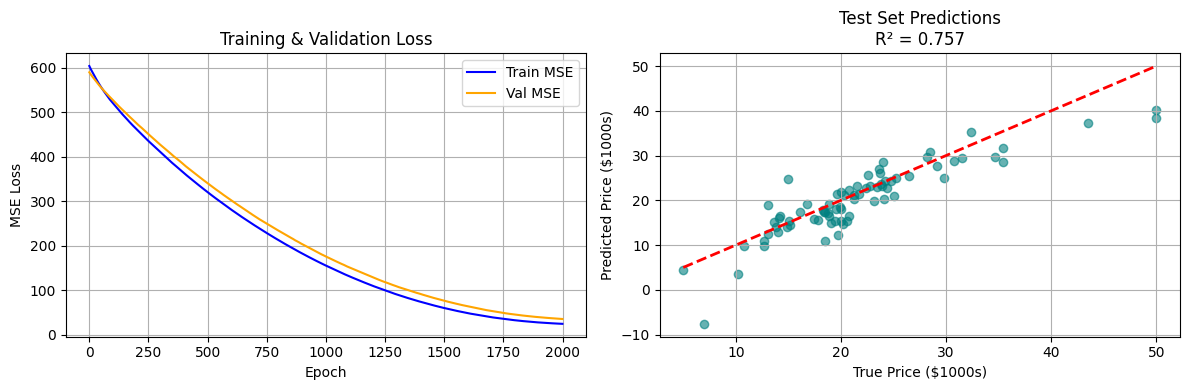

In [22]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train MSE", color="blue")
plt.plot(val_losses, label="Val MSE", color="orange")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

# Prediction vs True
plt.subplot(1, 2, 2)
plt.scatter(y_true_test, y_pred_test, alpha=0.6, color="teal")
plt.plot([y_true_test.min(), y_true_test.max()],[y_true_test.min(), y_true_test.max()], 'r--', lw=2)
plt.xlabel("True Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.title(f"Test Set Predictions\nR² = {r2_test:.3f}")
plt.grid(True)

plt.tight_layout()
plt.show()